Part I: Randomized Sales Data Generation (NumPy)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROLL_NO = 71
np.random.seed(ROLL_NO)

In [7]:
sales_data = np.random.randint(1000, 5001, size=(12, 4))
print(sales_data)
print(f"\nShape: {sales_data.shape}")

[[4888 2040 1769 2408]
 [4821 3731 4048 1557]
 [1319 4088 3583 4928]
 [4680 3149 2704 2106]
 [4251 1766 2396 2743]
 [2465 2743 1128 2262]
 [2635 2274 1322 3483]
 [3768 4154 2904 4487]
 [3842 3430 1192 1533]
 [4822 1935 4459 2603]
 [3254 3012 2923 3947]
 [1855 2372 2356 1701]]

Shape: (12, 4)


In [8]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
categories = ['Electronics','Clothing','Home & Kitchen','Sports']

df = pd.DataFrame(sales_data, index=months, columns=categories)
df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,4888,2040,1769,2408
Feb,4821,3731,4048,1557
Mar,1319,4088,3583,4928
Apr,4680,3149,2704,2106
May,4251,1766,2396,2743
Jun,2465,2743,1128,2262
Jul,2635,2274,1322,3483
Aug,3768,4154,2904,4487
Sep,3842,3430,1192,1533
Oct,4822,1935,4459,2603


Part II: Data Manipulation and Analysis (Pandas)

In [17]:
# First 5 rows
df.head()


,Electronics,Clothing,Home & Kitchen,Sports
Jan,4888,2040,1769,2408
Feb,4821,3731,4048,1557
Mar,1319,4088,3583,4928
Apr,4680,3149,2704,2106
May,4251,1766,2396,2743


In [18]:
# Summary statistics
df.describe()

,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,3550.000000,2891.166667,2565.333333,2813.166667
std,1238.665337,835.628216,1099.018515,1147.301643
min,1319.000000,1766.000000,1128.000000,1533.000000
25%,2592.500000,2215.500000,1657.250000,2004.750000
50%,3805.000000,2877.500000,2550.000000,2505.500000
75%,4715.250000,3505.250000,3088.000000,3599.000000
max,4888.000000,4154.000000,4459.000000,4928.000000


In [12]:
# Total sales per category
total_category = df.sum()
print("Total Sales per Category:\n", total_category)

# Total sales per month
total_month = df.sum(axis=1)
print("\nTotal Sales per Month:\n", total_month)

Total Sales per Category:
 Electronics       42600
Clothing          34694
Home & Kitchen    30784
Sports            33758
dtype: int64

Total Sales per Month:
 Jan    11105
Feb    14157
Mar    13918
Apr    12639
May    11156
Jun     8598
Jul     9714
Aug    15313
Sep     9997
Oct    13819
Nov    13136
Dec     8284
dtype: int64


In [20]:
# Average Sales Growth between Consecutive Months
# multiply pct_change() value by 100 to get percentage change
monthly_growth = df.pct_change()*100
avg_growth = monthly_growth.mean()
print("Monthly Growth Rate per Category: ")
print(monthly_growth)
print("\nAverage Growth Rate per Category: ")
print(avg_growth)

Monthly Growth Rate per Category: 
     Electronics   Clothing  Home & Kitchen      Sports
Jan          NaN        NaN             NaN         NaN
Feb    -1.370704  82.892157      128.829847  -35.340532
Mar   -72.640531   9.568480      -11.487154  216.506101
Apr   254.814253 -22.969667      -24.532515  -57.264610
May    -9.166667 -43.918704      -11.390533   30.246914
Jun   -42.013644  55.322763      -52.921536  -17.535545
Jul     6.896552 -17.098068       17.198582   53.978780
Aug    42.998102  82.673703      119.667171   28.825725
Sep     1.963907 -17.428984      -58.953168  -65.834633
Oct    25.507548 -43.586006      274.077181   69.797782
Nov   -32.517628  55.658915      -34.447185   51.632731
Dec   -42.993239 -21.248340      -19.397879  -56.903978

Average Growth Rate per Category: 
Electronics       11.952541
Clothing          10.896932
Home & Kitchen    29.694801
Sports            19.828067
dtype: float64


In [21]:
# Add 'Total Sales' and 'Growth Rate' Columns
df['Total Sales'] = df[categories].sum(axis=1)
df['Growth Rate'] = df['Total Sales'].pct_change()*100

print("DataFrame with New Columns: ")
print(df)


DataFrame with New Columns: 
     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan         4888      2040            1769    2408        11105          NaN
Feb         4821      3731            4048    1557        14157    27.483116
Mar         1319      4088            3583    4928        13918    -1.688211
Apr         4680      3149            2704    2106        12639    -9.189539
May         4251      1766            2396    2743        11156   -11.733523
Jun         2465      2743            1128    2262         8598   -22.929365
Jul         2635      2274            1322    3483         9714    12.979763
Aug         3768      4154            2904    4487        15313    57.638460
Sep         3842      3430            1192    1533         9997   -34.715601
Oct         4822      1935            4459    2603        13819    38.231469
Nov         3254      3012            2923    3947        13136    -4.942471
Dec         1855      2372            2356    1

In [22]:
df_discounted = df.copy()
if ROLL_NO % 2 == 0:
    df_discounted["Electronics"] = df_discounted["Electronics"] * 0.9
    discount_applied = "10% discount applied to Electronics"
else:
    df_discounted["Clothing"] = df_discounted["Clothing"] * 0.85
    discount_applied = "15% discount applied to Clothing"
discount_applied, df_discounted.head()

('15% discount applied to Clothing',
      Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
 Jan         4888   1734.00            1769    2408        11105          NaN
 Feb         4821   3171.35            4048    1557        14157    27.483116
 Mar         1319   3474.80            3583    4928        13918    -1.688211
 Apr         4680   2676.65            2704    2106        12639    -9.189539
 May         4251   1501.10            2396    2743        11156   -11.733523)

Part III: Visualizations (Matplotlib and Seaborn)

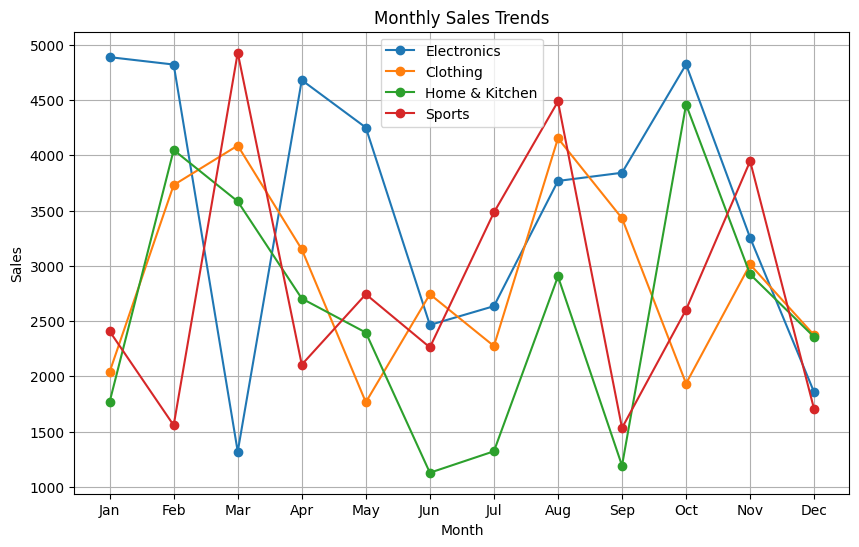

In [23]:
plt.figure(figsize=(10,6))

for col in categories:
    plt.plot(df.index, df[col], marker='o', label=col)

plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()

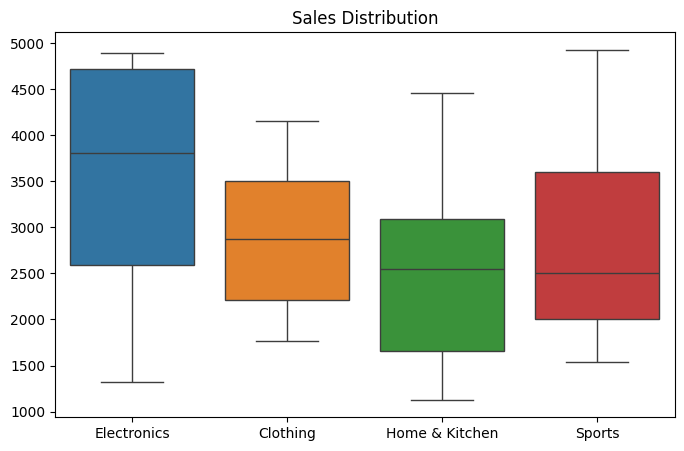

In [24]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df[categories])

plt.title("Sales Distribution")
plt.show()

Q2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])

In [27]:
array = np.array([[1,-2,3], [-4, 5, -6]])
# Absolute
abs_array = np.abs(array)
print("Absolute:\n", abs_array)

# Percentiles
print("\nFlattened Percentiles:", np.percentile(array.flatten(), [25,50,75]))
print("\nColumn Percentiles:\n", np.percentile(array, [25,50,75], axis=0))
print("\nRow Percentiles:\n", np.percentile(array, [25,50,75], axis=1))

# Mean, Median, Std
print("\nMean:", np.mean(array))
print("Median:", np.median(array))
print("Std:", np.std(array))

print("\nColumn-wise Mean:", np.mean(array, axis=0))
print("Row-wise Mean:", np.mean(array, axis=1))

Absolute:
 [[1 2 3]
 [4 5 6]]

Flattened Percentiles: [-3.5 -0.5  2.5]

Column Percentiles:
 [[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]

Row Percentiles:
 [[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]

Mean: -0.5
Median: -0.5
Std: 3.8622100754188224

Column-wise Mean: [-1.5  1.5 -1.5]
Row-wise Mean: [ 0.66666667 -1.66666667]


Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).

In [28]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

print("Floor:", np.floor(a))
print("Ceil:", np.ceil(a))
print("Truncate:", np.trunc(a))
print("Round:", np.round(a))

Floor: [-2. -2. -1.  0.  1.  1.  3.]
Ceil: [-1. -1. -0.  1.  2.  2.  3.]
Trunc: [-1. -1. -0.  0.  1.  1.  3.]
Round: [-2. -2. -0.  0.  2.  2.  3.]


Q4 WAP to swap two elements in a list in Python Using a Temporary Variable.

In [35]:
lst = [20,30,50,80,101,200]

i, j = 2, 5

temp = lst[i]
lst[i] = lst[j]
lst[j] = temp

print("Swapped List:", lst)

Swapped List: [20, 30, 200, 80, 101, 50]


Q5 Write a Python program to swap two elements in a set by converting it to a list first.

In [36]:
s = {10, 20, 30, 40}

lst = list(s)

i, j = 0, 2

temp = lst[i]
lst[i] = lst[j]
lst[j] = temp

s = set(lst)

print("Swapped Set:", s)

Swapped Set: {40, 10, 20, 30}
